### A. 資料介接 (Data Ingestion)

#### 水利署河川面 Shapefile（gpd.read_file(WRA_URL)）

In [49]:
import requests
import geopandas as gpd
import zipfile
import io

url = "https://gic.wra.gov.tw/Gis/gic/API/Google/DownLoad.aspx?fname=RIVERPOLY&filetype=SHP"

# 下載 zip
r = requests.get(url)

# 解壓縮
with zipfile.ZipFile(io.BytesIO(r.content)) as z:
    z.extractall("RIVERPOLY")

# 讀取 shapefile (注意資料夾層級)
rivers = gpd.read_file("RIVERPOLY/riverpoly/riverpoly.shp")

print(f"CRS: {rivers.crs}")
print(f"Geometry type: {rivers.geom_type.unique()}")
print(f"Rows: {len(rivers)}")

rivers.head()

CRS: EPSG:3826
Geometry type: <StringArray>
['Polygon', 'MultiPolygon']
Length: 2, dtype: str
Rows: 13262


,RIVER_NAME,RIVER_TYPE,RIVER_CODE,RIVER_FROM,geometry
0,基隆河,1,114030110.0,淡水河,"POLYGON ((329700.702 2778440.466, 329718.3 277..."
1,田寮河,5,NaN,NaN,"POLYGON ((330452.047 2778680.465, 330452.544 2..."
2,田寮河,5,NaN,NaN,"POLYGON ((330486.34 2779079.311, 330484.371 27..."
3,大武崙溪,5,NaN,NaN,"POLYGON ((321810.122 2781340.98, 321802.121 27..."
4,大武崙溪,5,NaN,NaN,"POLYGON ((321948.219 2780818.024, 321957.18 27..."


#### 消防署避難收容所 CSV（data.gov.tw/dataset/73242）

In [50]:
import pandas as pd

shelters_csv = pd.read_csv('data/shelters_cleaned.csv')  # 自行下載後放入 data/
shelters = gpd.GeoDataFrame(
    shelters_csv,
    geometry=gpd.points_from_xy(shelters_csv['經度'], shelters_csv['緯度']),
    crs='EPSG:4326'
)
print(f"CRS: {shelters.crs}")
shelters = shelters.to_crs('EPSG:3826')
print(f"New CRS: {shelters.crs}")
print(f"shelters geometry type: {shelters.geom_type.unique()}")
print(f"Shape: {shelters.shape}")
print(f"Rows: {len(shelters)}")

shelters.head()

CRS: EPSG:4326
New CRS: EPSG:3826
shelters geometry type: <StringArray>
['Point']
Length: 1, dtype: str
Shape: (5907, 19)
Rows: 5907


,序號,縣市及鄉鎮市區,村里,避難收容處所地址,經度,緯度,避難收容處所名稱,預計收容村里,預計收容人數,適用災害類別,管理人姓名,管理人電話,室內,室外,適合避難弱者安置,TWD97_lon,TWD97_lat,is_indoor,geometry
0,1,新竹縣,NaN,NaN,121.073000,24.386000,五峰活動中心,大隘村、花園村、桃山村、竹林村,110,"水災,震災,土石流",張兒,03-5851001,是,否,是,257404.817069,2.697775e+06,True,POINT (257404.817 2697774.55)
1,2,金門縣烈嶼鄉,林湖村,東林24號,118.248571,24.428328,金門縣烈嶼鄉林湖村辦公處,林湖村,30,"水災,震災,土石流,海嘯",林妙玲,082-364503,是,否,是,-29071.526021,2.705233e+06,True,POINT (-29071.526 2705233.104)
2,3,新竹縣北埔鄉,南坑村,9鄰大南坑1-5號,121.056100,24.672500,南坑村集會所暨南外社區活動中心,南坑村、外坪村,20,"水災,震災,土石流",葉貴霖,03-5805355,否,否,否,255677.652240,2.729505e+06,True,POINT (255677.652 2729505.027)
3,4,金門縣烏坵鄉,小坵村,無門牌號碼,119.470000,24.980000,烏坵鄉小坵村活動中心,小坵村,20,NaN,莊金輝,82666056,否,否,否,95524.923026,2.764433e+06,True,POINT (95524.923 2764433.473)
4,5,金門縣烏坵鄉,大坵村,1號,119.453178,24.988739,金門縣烏坵鄉公所大廳,烏坵鄉大坵村,30,NaN,林文彩,0826-66056,否,否,否,93837.281634,2.765421e+06,True,POINT (93837.282 2765420.913)


#### 國土測繪中心鄉鎮市區界

In [51]:
import geopandas as gpd
from urllib.parse import quote
# --- Read directly from TGOS (run as-is, no blanks) ---
# This zip has 2 layers — we need layer 1 (all 368 townships)
TGOS_BASE = 'https://www.tgos.tw/tgos/VirtualDir/Product/3fe61d4a-ca23-4f45-8aca-4a536f40f290/'
FILENAME  = '鄉(鎮、市、區)界線1140318.zip'
url = TGOS_BASE + quote(FILENAME)
print(url)
print('Reading township boundaries from TGOS ...')
townships = gpd.read_file(url, layer='TOWN_MOI_1140318')
# --- Fill in the blanks ---
print('Shape:', townships.shape)      # How many rows × columns?
print('CRS  :', townships.crs)      # What coordinate system?
townships.to_crs(epsg=3826, inplace=True)
print('New CRS  :', townships.crs)
print('Columns:', townships.columns.tolist())  # What columns exist?
print()
townships.head()

https://www.tgos.tw/tgos/VirtualDir/Product/3fe61d4a-ca23-4f45-8aca-4a536f40f290/%E9%84%89%28%E9%8E%AE%E3%80%81%E5%B8%82%E3%80%81%E5%8D%80%29%E7%95%8C%E7%B7%9A1140318.zip
Reading township boundaries from TGOS ...
Shape: (368, 8)
CRS  : GEOGCS["GCS_TWD97[2020]",DATUM["Taiwan_Datum_1997",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1026"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]
New CRS  : EPSG:3826
Columns: ['TOWNID', 'TOWNCODE', 'COUNTYNAME', 'TOWNNAME', 'TOWNENG', 'COUNTYID', 'COUNTYCODE', 'geometry']



,TOWNID,TOWNCODE,COUNTYNAME,TOWNNAME,TOWNENG,COUNTYID,COUNTYCODE,geometry
0,V02,10014020,臺東縣,成功鎮,Chenggong Township,V,10014,"POLYGON ((286994.568 2569686.978, 287066.318 2..."
1,T21,10013210,屏東縣,佳冬鄉,Jiadong Township,T,10013,"POLYGON ((203528.677 2484633.419, 203536.121 2..."
2,P13,10009130,雲林縣,麥寮鄉,Mailiao Township,P,10009,"POLYGON ((178880.906 2634847.772, 178880.637 2..."
3,V11,10014110,臺東縣,綠島鄉,Lüdao Township,V,10014,"MULTIPOLYGON (((300508.457 2508651.739, 300539..."
4,V16,10014160,臺東縣,蘭嶼鄉,Lanyu Township,V,10014,"MULTIPOLYGON (((313194.739 2427361.112, 313146..."


#### Dissolve 並篩選出花蓮縣範圍

In [52]:
# 1. 將 townships 依 COUNTYNAME 聚合為 counties
counties = townships.dissolve(by="COUNTYNAME", as_index=False)

# 2. 篩選花蓮縣
hualien = counties[counties["COUNTYNAME"] == "花蓮縣"].copy()

# 3. 檢查是否有抓到資料
if hualien.empty:
    raise ValueError("找不到『花蓮縣』，請確認 COUNTYNAME 欄位名稱或文字是否一致")

# 4. 取得 geometry type
geom_type = hualien.geometry.iloc[0].geom_type

# 5. 計算面積（km²）
area_km2 = hualien.geometry.area.iloc[0] / 1_000_000

# 6. 印出結果
print("===== Hualien County (花蓮縣) =====")
print("Geometry type:", geom_type)
print("Area (km²):", round(area_km2, 2))

# 7. 顯示該筆資料
display(hualien)

===== Hualien County (花蓮縣) =====
Geometry type: Polygon
Area (km²): 4605.28


,COUNTYNAME,geometry,TOWNID,TOWNCODE,TOWNNAME,TOWNENG,COUNTYID,COUNTYCODE
16,花蓮縣,"POLYGON ((288579.538 2575721.578, 288579.42 25...",U02,10015070,光復鄉,Guangfu Township,U,10015


#### 內政部地政司 20m DEM 已裁切完畢至花蓮縣，同時確保了邊緣避難所的 500m 緩衝區不會超出 DEM 範圍

In [53]:
import rioxarray

# 在 Colab 中從 Google Drive 讀取
dem = rioxarray.open_rasterio('data/dem_20m_hualien.tif')
dem
print(dem.rio.crs)
print(dem.shape)

PROJCS["GCS_WGS_1984",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.25722356049,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",121],PARAMETER["scale_factor",0.9999],PARAMETER["false_easting",250000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
(1, 7054, 3997)


#### 確認河川有涵蓋你的目標縣市(花蓮縣)

In [54]:
rivers_in_county = gpd.sjoin(rivers, hualien, predicate='intersects')
print(f"河川面與目標縣市交集：{len(rivers_in_county)} 筆")
assert len(rivers_in_county) > 0, "⚠️ 河川資料未涵蓋目標縣市！請重新下載完整河川資料，不要篩選前 N 條"

河川面與目標縣市交集：651 筆


### B. 地形分析 (Terrain Analysis)

#### 坡度計算：從 DEM 計算 slope（度）

In [55]:
import numpy as np
dy, dx = np.gradient(dem.values[0], 20)  # 20m resolution
slope = np.degrees(np.arctan(np.sqrt(dx**2 + dy**2)))
print(slope)
slope_min = np.nanmin(slope)
slope_max = np.nanmax(slope)
slope_mean = np.nanmean(slope)
print("===== Slope Statistics =====")
print("Slope min (deg):", round(float(slope_min), 2))
print("Slope max (deg):", round(float(slope_max), 2))
print("Slope mean (deg):", round(float(slope_mean), 2))

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
===== Slope Statistics =====
Slope min (deg): 0.0
Slope max (deg): 89.97
Slope mean (deg): 12.66


#### Zonal Statistics：為每個避難所的 500m 緩衝區計算：
- 平均高程 (mean elevation)
- 最大坡度 (max slope)
- 高程標準差 (std elevation) — 地形起伏度

In [56]:
# ===============================
# 篩選花蓮縣內避難所 + 計算每個避難所500m緩衝區地形指標
# mean elevation / max slope / std elevation
# ===============================
import numpy as np
import geopandas as gpd
from rasterio.features import geometry_mask

# -------------------------------
# 1. 篩選出位於花蓮縣內的避難所點位
# -------------------------------
# hualien 為 GeoDataFrame，先合併成單一 polygon
hualien_geom = hualien.union_all()

# 只保留在花蓮縣範圍內的避難所
shelters_in_hualien = shelters[shelters.within(hualien_geom)].copy()

print(f"花蓮縣內避難所數量: {len(shelters_in_hualien)}")
assert len(shelters_in_hualien) > 0, "⚠️ 沒有避難所點位落在花蓮縣內，請檢查 CRS 或資料內容"

# -------------------------------
# 2. 建立 500m buffer
# -------------------------------
shelters_in_hualien["buffer_500m"] = shelters_in_hualien.geometry.buffer(500)

# -------------------------------
# 3. 準備 DEM / slope / transform / nodata
# -------------------------------
dem_array = dem.values[0].astype(float)
transform = dem.rio.transform()
nodata = dem.rio.nodata

# 若 DEM 有 nodata，先轉成 np.nan
if nodata is not None:
    dem_array = np.where(dem_array == nodata, np.nan, dem_array)

# slope 也同步遮掉 DEM 的 nan
slope_array = np.where(np.isnan(dem_array), np.nan, slope)

# -------------------------------
# 4. 定義函式：對單一 buffer 計算統計值
# -------------------------------
def calc_buffer_topo_stats(buffer_geom, dem_arr, slope_arr, transform):
    # geometry_mask: True = outside, False = inside
    mask = geometry_mask(
        [buffer_geom],
        transform=transform,
        invert=True,
        out_shape=dem_arr.shape
    )

    elev_vals = dem_arr[mask]
    slope_vals = slope_arr[mask]

    # 去除 nan
    elev_vals = elev_vals[~np.isnan(elev_vals)]
    slope_vals = slope_vals[~np.isnan(slope_vals)]

    if len(elev_vals) == 0:
        return np.nan, np.nan, np.nan

    mean_elev = float(np.mean(elev_vals))
    max_slope = float(np.max(slope_vals)) if len(slope_vals) > 0 else np.nan
    std_elev  = float(np.std(elev_vals))

    return mean_elev, max_slope, std_elev

# -------------------------------
# 5. 逐一計算每個避難所 500m buffer 的統計
# -------------------------------
stats = shelters_in_hualien["buffer_500m"].apply(
    lambda geom: calc_buffer_topo_stats(geom, dem_array, slope_array, transform)
)

shelters_in_hualien[["mean_elevation", "max_slope", "std_elevation"]] = pd.DataFrame(
    stats.tolist(),
    index=shelters_in_hualien.index
)

# -------------------------------
# 6. 顯示結果
# -------------------------------
print("===== 完成每個避難所500m緩衝區地形統計 =====")
print(shelters_in_hualien[["mean_elevation", "max_slope", "std_elevation"]].describe())

display(
    shelters_in_hualien[
        ["mean_elevation", "max_slope", "std_elevation", "geometry"]
    ].head()
)
shelters_in_hualien.to_csv("shelters_in_hualien.csv", index=False, encoding="utf-8-sig")

花蓮縣內避難所數量: 198
===== 完成每個避難所500m緩衝區地形統計 =====
       mean_elevation   max_slope  std_elevation
count      198.000000  198.000000     198.000000
mean       105.585710   27.132475      16.694863
std        131.453937   21.757292      27.691072
min          5.557756    3.791913       0.958553
25%         23.975732    8.889212       2.514850
50%         82.220809   18.342414       4.938766
75%        150.031299   43.595323      24.068638
max       1150.632225   89.950562     224.635322


,mean_elevation,max_slope,std_elevation,geometry
29,27.502351,45.473251,17.994240,POINT (326011.111 2689346.508)
1272,299.459149,41.046368,13.260633,POINT (277505.779 2560143.417)
1298,240.630908,29.891891,7.838210,POINT (274563.447 2562153.682)
1308,257.456815,32.286247,22.753039,POINT (276261.145 2563286.086)
1316,238.324347,30.526333,18.284005,POINT (275351.804 2563630.784)


### C. 複合風險判定 (Composite Risk)

#### 風險分級邏輯：
- 極高風險：距河川 < 500m 且 最大坡度 > SLOPE_THRESHOLD
- 高風險：距河川 < 500m 或 最大坡度 > SLOPE_THRESHOLD
- 中風險：距河川 < 1000m 且 平均高程 < ELEVATION_LOW
- 低風險：其餘

In [57]:
# ===============================
# 從 .env 讀取門檻值 + 河川切至花蓮 + 風險分級
# ===============================
import os
import numpy as np
import geopandas as gpd
from dotenv import load_dotenv

# -------------------------------
# 1. 讀取 .env 參數
# -------------------------------
load_dotenv()

SLOPE_THRESHOLD = float(os.getenv("SLOPE_THRESHOLD", 30))
ELEVATION_LOW   = float(os.getenv("ELEVATION_LOW", 50))
BUFFER_HIGH     = float(os.getenv("BUFFER_HIGH", 500))
BUFFER_MEDIUM   = float(os.getenv("BUFFER_MEDIUM", 1000))
TARGET_COUNTY   = os.getenv("TARGET_COUNTY", "花蓮縣")

print("===== Parameters from .env =====")
print("SLOPE_THRESHOLD =", SLOPE_THRESHOLD)
print("ELEVATION_LOW   =", ELEVATION_LOW)
print("BUFFER_HIGH     =", BUFFER_HIGH)
print("BUFFER_MEDIUM   =", BUFFER_MEDIUM)
print("TARGET_COUNTY   =", TARGET_COUNTY)

# -------------------------------
# 2. 重新依 TARGET_COUNTY 取得目標縣市 polygon
# -------------------------------
target_county = counties[counties["COUNTYNAME"] == TARGET_COUNTY].copy()

if target_county.empty:
    raise ValueError(f"找不到目標縣市：{TARGET_COUNTY}，請確認 .env 中 TARGET_COUNTY 是否正確")

target_geom = target_county.union_all()

# -------------------------------
# 3. 將河川資料切至目標縣市範圍
# -------------------------------
# 先確認 CRS 一致
if rivers.crs != target_county.crs:
    rivers = rivers.to_crs(target_county.crs)

# 先篩可能相交者，再 clip
rivers_in_county = gpd.clip(rivers, target_county)

print(f"切至 {TARGET_COUNTY} 範圍內的河川筆數: {len(rivers_in_county)}")
assert len(rivers_in_county) > 0, f"⚠️ {TARGET_COUNTY} 範圍內沒有河川資料，請檢查圖資"

# -------------------------------
# 4. 建立河川 buffer
#    - high: 河川外擴 500m
#    - medium: 河川外擴 1000m
#    - ring_500_1000: 500m~1000m 環域
# -------------------------------
river_union = rivers_in_county.union_all()

river_buffer_high = gpd.GeoDataFrame(
    geometry=[river_union.buffer(BUFFER_HIGH)],
    crs=rivers_in_county.crs
)

river_buffer_medium = gpd.GeoDataFrame(
    geometry=[river_union.buffer(BUFFER_MEDIUM)],
    crs=rivers_in_county.crs
)

# 500~1000m 環域 = 1000m buffer - 500m buffer
river_ring_500_1000_geom = river_union.buffer(BUFFER_MEDIUM).difference(
    river_union.buffer(BUFFER_HIGH)
)

river_ring_500_1000 = gpd.GeoDataFrame(
    geometry=[river_ring_500_1000_geom],
    crs=rivers_in_county.crs
)

# -------------------------------
# 5. 確保 shelters_in_hualien 存在且為目標縣市內
# -------------------------------
# 若你前面已經有 shelters_in_hualien，這裡直接沿用
# 但為了讓此 cell 更穩定，重新依 target county 篩一次
shelters_in_county = shelters[shelters.within(target_geom)].copy()

print(f"{TARGET_COUNTY} 內避難所數量: {len(shelters_in_county)}")
assert len(shelters_in_county) > 0, f"⚠️ {TARGET_COUNTY} 內沒有避難所，請檢查 CRS 或資料"

# -------------------------------
# 6. 若尚未有 mean_elevation / max_slope / std_elevation，提醒使用者
# -------------------------------
required_cols = ["mean_elevation", "max_slope", "std_elevation"]
missing_cols = [c for c in required_cols if c not in shelters_in_county.columns]

# 若 shelters_in_hualien 已經算完，但 shelters_in_county 是重新篩的副本，
# 就從 shelters_in_hualien merge 回來
if len(missing_cols) > 0 and "shelters_in_hualien" in globals():
    stats_cols = [c for c in required_cols if c in shelters_in_hualien.columns]
    if len(stats_cols) == len(required_cols):
        shelters_in_county = shelters_in_county.merge(
            shelters_in_hualien[stats_cols + ["geometry"]].drop_duplicates(),
            on="geometry",
            how="left"
        )

missing_cols = [c for c in required_cols if c not in shelters_in_county.columns]
if len(missing_cols) > 0:
    raise ValueError(
        f"缺少欄位 {missing_cols}。請先執行前一個 cell，完成 mean_elevation / max_slope / std_elevation 計算。"
    )

# -------------------------------
# 7. 計算每個避難所到河川的最短距離
# -------------------------------
# river_union 是 MultiPolygon / Polygon
# 直接用幾何距離即可，單位為公尺（因 CRS=EPSG:3826）
shelters_in_county["river_distance_m"] = shelters_in_county.geometry.distance(river_union)

# -------------------------------
# 8. 河川距離分級
# -------------------------------
def classify_river_distance(dist):
    if dist < BUFFER_HIGH:
        return "小於500公尺"
    elif dist < BUFFER_MEDIUM:
        return "500-1000公尺之間"
    else:
        return "1000公尺以上"

shelters_in_county["river_distance_category"] = shelters_in_county["river_distance_m"].apply(classify_river_distance)

# -------------------------------
# 9. 風險分級邏輯
# -------------------------------
def classify_risk(row):
    dist = row["river_distance_m"]
    max_slope = row["max_slope"]
    mean_elev = row["mean_elevation"]

    # 極高風險：距河川 < 500m 且 最大坡度 > SLOPE_THRESHOLD
    if (dist < BUFFER_HIGH) and (max_slope > SLOPE_THRESHOLD):
        return "極高風險"

    # 高風險：距河川 < 500m 或 最大坡度 > SLOPE_THRESHOLD
    elif (dist < BUFFER_HIGH) or (max_slope > SLOPE_THRESHOLD):
        return "高風險"

    # 中風險：距河川 < 1000m 且 平均高程 < ELEVATION_LOW
    elif (dist < BUFFER_MEDIUM) and (mean_elev < ELEVATION_LOW):
        return "中風險"

    # 低風險：其餘
    else:
        return "低風險"

shelters_in_county["risk_level"] = shelters_in_county.apply(classify_risk, axis=1)

# -------------------------------
# 10. 依需求整理輸出欄位
# -------------------------------
output_cols = [
    "mean_elevation",
    "max_slope",
    "std_elevation",
    "river_distance_m",
    "river_distance_category",
    "risk_level",
    "geometry"
]

result = shelters_in_county[output_cols].copy()

print("===== Risk Classification Summary =====")
print(result["risk_level"].value_counts(dropna=False))
print()
print(result["river_distance_category"].value_counts(dropna=False))

display(result.head())

# 若你希望後續沿用這個變數名稱
shelters_in_hualien = shelters_in_county.copy()
shelters_in_hualien.to_file("outputs/terrain_risk_audit.geojson", driver="GeoJSON", encoding="utf-8")

===== Parameters from .env =====
SLOPE_THRESHOLD = 30.0
ELEVATION_LOW   = 50.0
BUFFER_HIGH     = 500.0
BUFFER_MEDIUM   = 1000.0
TARGET_COUNTY   = 花蓮縣
切至 花蓮縣 範圍內的河川筆數: 651
花蓮縣 內避難所數量: 198
===== Risk Classification Summary =====
risk_level
高風險     71
極高風險    53
低風險     52
中風險     22
Name: count, dtype: int64

river_distance_category
小於500公尺         93
500-1000公尺之間    60
1000公尺以上        45
Name: count, dtype: int64


,mean_elevation,max_slope,std_elevation,river_distance_m,river_distance_category,risk_level,geometry
0,27.502351,45.473251,17.994240,865.673162,500-1000公尺之間,高風險,POINT (326011.111 2689346.508)
1,299.459149,41.046368,13.260633,53.524272,小於500公尺,極高風險,POINT (277505.779 2560143.417)
2,240.630908,29.891891,7.838210,277.175989,小於500公尺,高風險,POINT (274563.447 2562153.682)
3,257.456815,32.286247,22.753039,342.785916,小於500公尺,極高風險,POINT (276261.145 2563286.086)
4,238.324347,30.526333,18.284005,294.440576,小於500公尺,極高風險,POINT (275351.804 2563630.784)


### D. 視覺化 (Visualization)

#### DEM + 避難所地圖：用 matplotlib 疊合 DEM hillshade + 避難所點位（依風險等級著色）

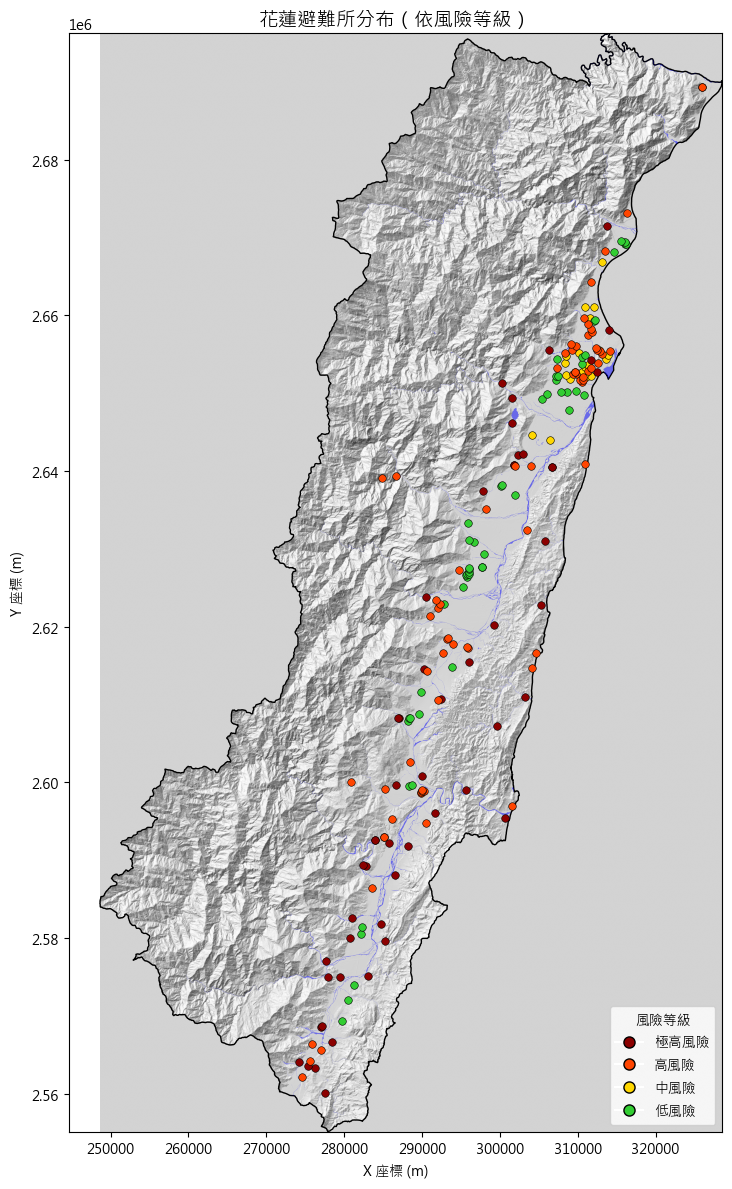

In [58]:
# ===============================
# DEM hillshade + 避難所風險分級地圖（中文優化版）
# ===============================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import LightSource

# -------------------------------
# 0. 設定中文字型（關鍵）
# -------------------------------
plt.rcParams['font.sans-serif'] = [
    'Microsoft JhengHei',  # Windows 常見
    'SimHei',              # Colab / Linux 常見
    'Arial Unicode MS'
]
plt.rcParams['axes.unicode_minus'] = False  # 避免負號變方塊

# -------------------------------
# 1. DEM hillshade
# -------------------------------
dem_array = dem.values[0].astype(float)
nodata = dem.rio.nodata

if nodata is not None:
    dem_array = np.where(dem_array == nodata, np.nan, dem_array)

transform = dem.rio.transform()

x_min = transform.c
x_max = x_min + transform.a * dem_array.shape[1]
y_max = transform.f
y_min = y_max + transform.e * dem_array.shape[0]

extent = [x_min, x_max, y_min, y_max]

ls = LightSource(azdeg=315, altdeg=45)
fill_value = np.nanmean(dem_array)
dem_filled = np.where(np.isnan(dem_array), fill_value, dem_array)

hillshade = ls.hillshade(dem_filled, vert_exag=1, dx=20, dy=20)

# -------------------------------
# 2. 顏色設定
# -------------------------------
risk_color_map = {
    "極高風險": "darkred",
    "高風險": "orangered",
    "中風險": "gold",
    "低風險": "limegreen"
}

shelters_plot = shelters_in_hualien.copy()
shelters_plot["plot_color"] = shelters_plot["risk_level"].map(risk_color_map).fillna("gray")

# -------------------------------
# 3. 繪圖
# -------------------------------
fig, ax = plt.subplots(figsize=(10, 12))

# 底圖
ax.imshow(
    hillshade,
    extent=extent,
    origin="upper",
    cmap="gray",
    zorder=0
)

# 花蓮邊界
hualien.boundary.plot(ax=ax, linewidth=1, edgecolor="black",zorder=1)

# 河川
rivers_in_county.plot(ax=ax, color="blue", alpha=0.5, linewidth=0.3,zorder=2)

# 避難所點位
for risk_level, group in shelters_plot.groupby("risk_level"):
    group.plot(
        ax=ax,
        markersize=30,
        color=risk_color_map.get(risk_level, "gray"),
        edgecolor="black",
        linewidth=0.4,
        label=risk_level,
        zorder=10
    )

# -------------------------------
# 4. 圖例（改到右下角）
# -------------------------------
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='極高風險',
           markerfacecolor=risk_color_map["極高風險"], markeredgecolor='black', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='高風險',
           markerfacecolor=risk_color_map["高風險"], markeredgecolor='black', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='中風險',
           markerfacecolor=risk_color_map["中風險"], markeredgecolor='black', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='低風險',
           markerfacecolor=risk_color_map["低風險"], markeredgecolor='black', markersize=8),
]

ax.legend(
    handles=legend_elements,
    title="風險等級",
    loc="lower right",  
    frameon=True
)

# -------------------------------
# 5. 標題與座標
# -------------------------------
ax.set_title("花蓮避難所分布（依風險等級）", fontsize=14)
ax.set_xlabel("X 座標 (m)")
ax.set_ylabel("Y 座標 (m)")
ax.set_aspect("equal")

plt.savefig("outputs/terrain_risk_map.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


#### 繪製統計圖：Top 10 高風險避難所的坡度 vs. 高程散佈圖

極高風險避難所數量: 53
===== Top 10 極高風險避難所 =====


,mean_elevation,max_slope,river_distance_category,risk_index
146,9.308029,89.950546,小於500公尺,0.850000
177,17.134883,89.950539,小於500公尺,0.844605
195,87.577001,70.428528,小於500公尺,0.632060
45,63.718883,66.628502,小於500公尺,0.616585
79,83.961822,63.652252,小於500公尺,0.577630
62,36.283165,57.256416,小於500公尺,0.556769
37,18.596167,54.610340,小於500公尺,0.546733
128,179.414936,65.691605,小於500公尺,0.528966
19,188.470148,62.642925,小於500公尺,0.497115
53,108.427557,54.413998,小於500公尺,0.483163


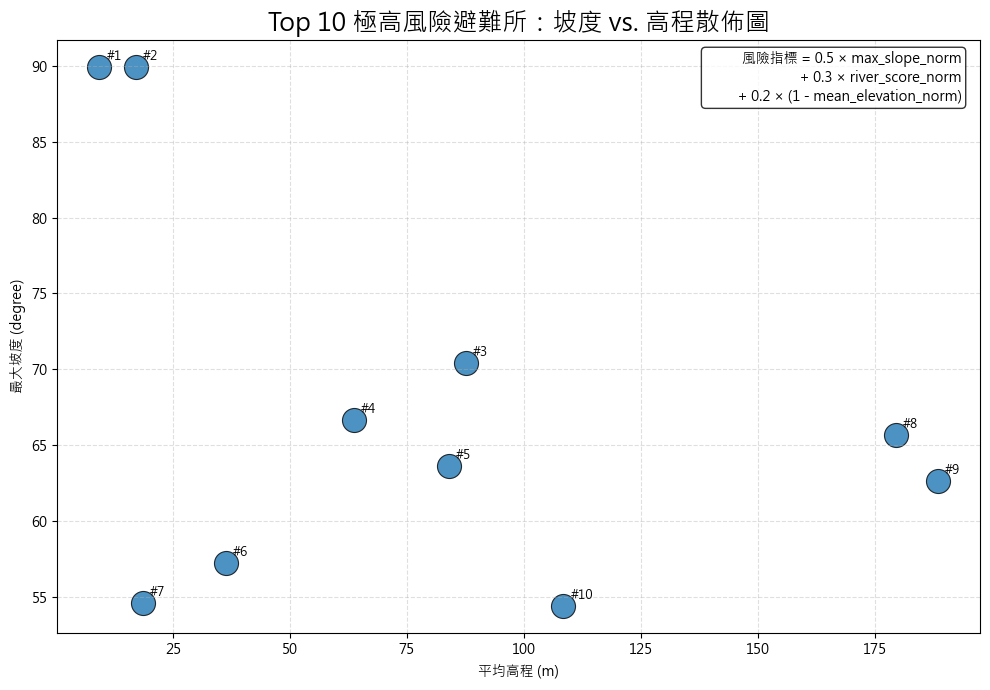

In [59]:
# ===============================
# Top 10 極高風險避難所：坡度 vs. 高程散佈圖
# 自訂風險指標 = max_slope(最高權重) + river_distance_category(次高權重) + mean_elevation(最低權重)
# ===============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# 0. 中文字型設定
# -------------------------------
plt.rcParams['font.sans-serif'] = [
    'Microsoft JhengHei',
    'SimHei',
    'Arial Unicode MS'
]
plt.rcParams['axes.unicode_minus'] = False

# -------------------------------
# 1. 檢查必要欄位
# -------------------------------
required_cols = ["risk_level", "mean_elevation", "max_slope", "river_distance_category"]
missing_cols = [c for c in required_cols if c not in shelters_in_hualien.columns]
if missing_cols:
    raise ValueError(f"缺少必要欄位: {missing_cols}")

# -------------------------------
# 2. 篩選「極高風險」避難所
# -------------------------------
extreme_risk = shelters_in_hualien[
    shelters_in_hualien["risk_level"] == "極高風險"
].copy()

print(f"極高風險避難所數量: {len(extreme_risk)}")
assert len(extreme_risk) > 0, "沒有『極高風險』避難所可供分析"

# -------------------------------
# 3. river_distance_category 轉成分數
#    越靠近河川風險越高，分數越高
# -------------------------------
river_score_map = {
    "小於500公尺": 3,
    "500-1000公尺之間": 2,
    "1000公尺以上": 1
}

extreme_risk["river_score"] = extreme_risk["river_distance_category"].map(river_score_map)

# 若有未成功對應者，補成最低分
extreme_risk["river_score"] = extreme_risk["river_score"].fillna(1)

# -------------------------------
# 4. 建立風險指標公式
#    權重設定：
#    - max_slope: 權重最大
#    - river_score: 權重次之
#    - mean_elevation: 權重最小
#
#    因各欄位量綱不同，先做 min-max normalization
# -------------------------------
def minmax_normalize(series):
    s_min = series.min()
    s_max = series.max()
    if pd.isna(s_min) or pd.isna(s_max) or s_max == s_min:
        return pd.Series(np.ones(len(series)) * 0.5, index=series.index)
    return (series - s_min) / (s_max - s_min)

# max_slope：越大越危險
extreme_risk["max_slope_norm"] = minmax_normalize(extreme_risk["max_slope"])

# river_score：越大越危險
extreme_risk["river_score_norm"] = minmax_normalize(extreme_risk["river_score"])

# mean_elevation：
# 依你目前作業脈絡，低海拔通常較危險，所以這裡轉為「越低分數越高」
extreme_risk["mean_elevation_norm_inverse"] = 1 - minmax_normalize(extreme_risk["mean_elevation"])

# -------------------------------
# 5. 風險指標公式
#    建議權重：
#    slope 0.5 / river 0.3 / elevation 0.2
# -------------------------------
W_SLOPE = 0.5
W_RIVER = 0.3
W_ELEV  = 0.2

extreme_risk["risk_index"] = (
    W_SLOPE * extreme_risk["max_slope_norm"] +
    W_RIVER * extreme_risk["river_score_norm"] +
    W_ELEV  * extreme_risk["mean_elevation_norm_inverse"]
)

# -------------------------------
# 6. 取最高風險前 10 名
# -------------------------------
top10_risk = extreme_risk.sort_values("risk_index", ascending=False).head(10).copy()

print("===== Top 10 極高風險避難所 =====")
display_cols = ["mean_elevation", "max_slope", "river_distance_category", "risk_index"]
name_col = None

# 自動找可能的名稱欄位
possible_name_cols = ["避難所名稱", "name", "NAME", "shelter_name", "場所名稱", "收容所名稱"]
for col in possible_name_cols:
    if col in top10_risk.columns:
        name_col = col
        display_cols = [col] + display_cols
        break

display(top10_risk[display_cols])

# -------------------------------
# 7. 繪製散佈圖
#    x = mean_elevation
#    y = max_slope
#    點大小 = risk_index
# -------------------------------
fig, ax = plt.subplots(figsize=(10, 7))

sizes = 300

scatter = ax.scatter(
    top10_risk["mean_elevation"],
    top10_risk["max_slope"],
    s=sizes,
    alpha=0.8,
    edgecolors="black",
    linewidths=0.8
)

# 點位標註
if name_col is not None:
    for _, row in top10_risk.iterrows():
        ax.annotate(
            str(row[name_col]),
            (row["mean_elevation"], row["max_slope"]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=9
        )
else:
    # 若沒有名稱欄位，就標註排名
    for i, (_, row) in enumerate(top10_risk.iterrows(), start=1):
        ax.annotate(
            f"#{i}",
            (row["mean_elevation"], row["max_slope"]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=9
        )

# 軸與標題
ax.set_title("Top 10 極高風險避難所：坡度 vs. 高程散佈圖", fontsize=18)
ax.set_xlabel("平均高程 (m)")
ax.set_ylabel("最大坡度 (degree)")

# 加入網格
ax.grid(True, linestyle="--", alpha=0.4)

# 圖中補充公式說明
formula_text = (
    "風險指標 = 0.5 × max_slope_norm\n"
    "         + 0.3 × river_score_norm\n"
    "         + 0.2 × (1 - mean_elevation_norm)"
)
ax.text(
    0.98, 0.98,   
    formula_text,
    transform=ax.transAxes,
    fontsize=10,
    va="top",
    ha="right",   
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)
plt.savefig("outputs/top10_risk_shelters.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()